<a href="https://colab.research.google.com/github/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/notebooks/CNN_mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Description:

*   The main goal of this notebook is to show the same CNN model can be used regardless of the image dimension & class size for different datasets. The ML class is constructed such that varying inputs, outputs dimensions doesn't matter.
*   We are using the same CNN class from CIFAR10 model training




## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time
import os

# Check the device enabled

In [2]:
print(torch.__version__)
if torch.cuda.is_available():
  device = torch.device('cuda:0')
else:
  device = torch.device('cpu')
print(device)

2.8.0+cu126
cuda:0


## Import Datasets - MNIST

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.09MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]

5 torch.Size([1, 28, 28])


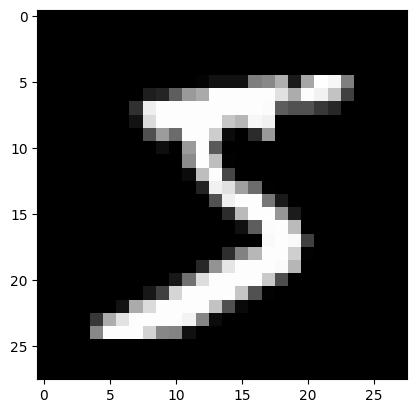

In [3]:
folder = "data"
mnist_train = datasets.MNIST(folder, train = True, download = True, transform = transforms.ToTensor())
mnist_test = datasets.MNIST(folder, train = False, download = True, transform = transforms.ToTensor())
print(mnist_train[0][1], mnist_train[0][0].shape)
plt.imshow(mnist_train[0][0].permute(1,2,0), cmap='gray')

## Normalize the Dataset

torch.Size([1, 28, 28, 60000])
torch.Size([1, 47040000])
tensor([0.1307]) tensor([0.3081])
5 torch.Size([1, 28, 28])


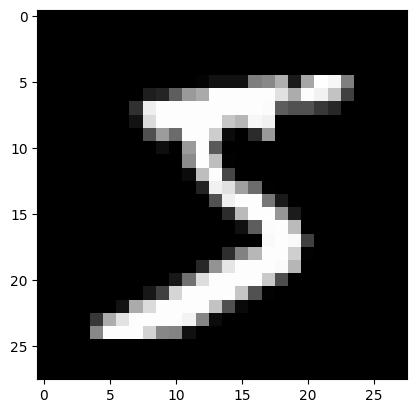

In [4]:
img_stack = torch.stack([img for img, _ in mnist_train], dim=3)
print(img_stack.shape)
img_flat = img_stack.view(1, -1)
print(img_flat.shape)
mu = img_flat.mean(dim = 1)
sigma = img_flat.std(dim=1)
print(mu, sigma)

mnist_train = datasets.MNIST(folder,
                             train = True,
                             download = False,
                             transform = transforms.Compose([
                                 transforms.ToTensor(),
                                 transforms.Normalize(mu, sigma)
                             ]))

mnist_val = datasets.MNIST(folder,
                           train = False,
                           download = False,
                           transform = transforms.Compose([
                               transforms.ToTensor(),
                               transforms.Normalize(mu, sigma)
                           ]))
print(mnist_train[0][1], mnist_train[0][0].shape)
plt.imshow(mnist_train[0][0].permute(1,2,0), cmap='gray')

## Define the CNN Model
This is the same CNN Model defined for CIFAR10 dataset

In [12]:
class NeuralNet(nn.Module):
  def __init__(self, img, nclasses, nchannels = 16, nhidden = 32, kernel_size = 3):
    super().__init__()
    C, H, W = img.shape
    self.conv1 = nn.Conv2d(C, nchannels, kernel_size = kernel_size, padding = kernel_size//2) # Padding used will keep same image dimensions
    self.conv2 = nn.Conv2d(nchannels, nchannels//2, kernel_size = kernel_size, padding = kernel_size//2) # Max pooling only reduces the spatial dims
    self.flat = H//4 * W//4 * nchannels//2
    self.fc1 = nn.Linear(self.flat, nhidden)
    self.fc2 = nn.Linear(nhidden, nclasses)

  def forward(self, x):
    out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
    out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
    out = out.view(-1, self.flat)
    out = torch.tanh(self.fc1(out))
    out = self.fc2(out)           # Depending on classification or regression problem use softmax else just use the raw logits
    return out

## Training loop

In [13]:
def training(nepochs, train_loader, model, loss_fn, optimizer, l_regularizer):
  for epoch in range(nepochs):
    loss_epoch = 0
    time_start = time.time()
    for imgs, labels in train_loader:
      imgs = imgs.to(device=device)
      labels = labels.to(device=device)
      outputs = model(imgs)             # Predicted Output
      loss = loss_fn(outputs, labels)

      l2_norm = sum(p.pow(2).sum() for p in model.parameters()) # Take square of all parameters within one layer, sum it, sum for all the layers
      loss = loss + l2_norm * l_regularizer

      optimizer.zero_grad() # Zero the gradients to avoid adding the current gradients with past gradients from 2 separate batches
      loss.backward()       # Calculate the loss backwards
      optimizer.step()      # Updates the model's parameters: weights & bias

      loss_epoch += loss.item()

    print(f"Epoch: {epoch+1}, Avg Train Loss per batch: {loss_epoch/len(train_loader)}")

## Train the Dataset

In [18]:
img = mnist_train[0][0]
img = img.to(device=device)

train_loader = torch.utils.data.DataLoader(mnist_train, batch_size = 64, shuffle = True) # Each batch has 64 images
model = NeuralNet(img, nclasses = 10).to(device = device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 1e-2)

training(
    nepochs = 10,
    train_loader = train_loader,
    model = model,
    loss_fn = loss_fn,
    optimizer = optimizer,
    l_regularizer = 0.001
)

Epoch: 1, Avg Train Loss per batch: 1.345385543350726
Epoch: 2, Avg Train Loss per batch: 0.5323728675971916
Epoch: 3, Avg Train Loss per batch: 0.3889945940072857
Epoch: 4, Avg Train Loss per batch: 0.32975380756516953
Epoch: 5, Avg Train Loss per batch: 0.2946866135130813
Epoch: 6, Avg Train Loss per batch: 0.2699537439259893
Epoch: 7, Avg Train Loss per batch: 0.25148867628276983
Epoch: 8, Avg Train Loss per batch: 0.2368657228820868
Epoch: 9, Avg Train Loss per batch: 0.2251555201277804
Epoch: 10, Avg Train Loss per batch: 0.21541422411704114
